# NLP: Disaster Tweets Competition

In this notebook, we will work with the [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started) Kaggle competition. The task is to predict whether a tweet refers to a real disaster or not.

We will use the provided `train.csv` dataset to experiment and develop our models, and then apply the final model to the `test.csv` dataset to generate a submission for the competition.

We will start by implementing a simple baseline model using a traditional Machine Learning approach: **TF-IDF + Logistic Regression**. This will provide an initial understanding of the data and establish a performance benchmark.

Once we establish the baseline, we will experiment with more complex models by fine-tuning different transformer architectures:

- **Tweet-specific models (RoBERTa-based)**:
  - `vinai/bertweet-base`
  - `vinai/bertweet-large`  
  We will evaluate whether increasing model size improves performance.

- **General-purpose language models (BERT-based)**:
  - `google-bert/bert-base-uncased`
  - `google-bert/bert-large-uncased`  

With these experiments, we aim to compare domain-specific models (trained on tweets) against general-purpose language models to determine whether domain alignment provides a measurable advantage.

For each model, we will perform hyperparameter optimization (HPO) and fine-tuning to evaluate performance improvements.

**H1:** Given the robustness and deeper contextual understanding of transformer-based models, we expect them to outperform the baseline model.

**H2:** Models pre-trained on tweet data (domain-specific) will outperform general-purpose language models such as BERT.

After training each model, we will conduct an error analysis loop, where we analyze model failures and iteratively refine our approach. This may include tuning hyperparameters, adjusting model architecture (e.g., number of layers), and improving preprocessing steps (such as handling emojis, hashtags, etc.), with the goal of maximizing performance before making a final submission.

## 0. Notebook Preparation

### 0.1 Import Dependencies

In [ ]:
!pip install evaluate optuna emoji -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import optuna
import torch

from scipy.special import softmax
from typing import Any
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from datasets import Dataset, DatasetDict, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from emoji import demojize

### 0.2 Load Dataset

In [7]:
DATASET_PATH = "/content/train.csv"
df = pd.read_csv(filepath_or_buffer=DATASET_PATH)

print(f"Dataset loaded successfully with {len(df)} examples")

Dataset loaded successfully with 7613 examples


---
## 1. Exploratory Data Analysis (EDA)

Before starting, we will perform Exploratory Data Analysis (EDA) to better understand the dataset, gather insights, and build intuition that will help us interpret model results and errors later on.

After completing the EDA, we will apply basic preprocessing and split the data into training, validation, and test sets. This will allow us to properly evaluate our models, since the `test.csv` file provided by the competition does not include labels.

### 1.1 Text Length vs Target
Let's calculate the length of each tweet and see if there's a significant difference in length between real disasters (1) and non-disasters (0).

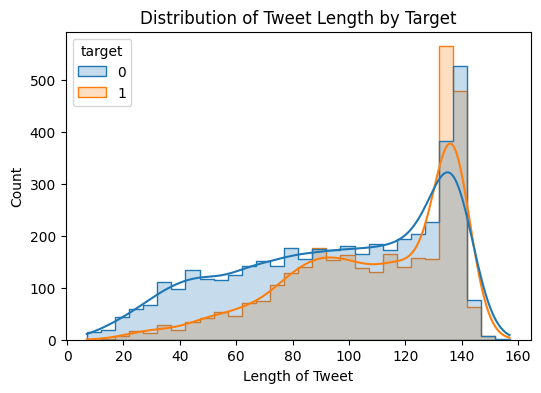

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4342.0,95.706817,35.885924,7.0,68.0,101.0,130.0,157.0
1,3271.0,108.113421,29.309854,14.0,88.0,115.0,136.0,151.0


In [15]:
df["text_len"] = df["text"].apply(len)

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="text_len", hue="target", kde=True, bins=30, element="step")
plt.title("Distribution of Tweet Length by Target")
plt.xlabel("Length of Tweet")
plt.ylabel("Count")
plt.show()

print("\n")
display(df.groupby("target")["text_len"].describe())

After reviewing the **Text Length vs Target** results, we observe that tweets from both classes have a generally similar length. The difference at the 75th percentile is only about 6 characters, indicating a small variation. However, tweets labeled as real disasters (1) tend to be slightly longer, especially in percentiles below the 50th, where the difference is more noticeable.

Additionally, and importantly, we can see that the dataset is imbalanced. There are 4,342 examples of NOT_DISASTER (0) and 3,271 examples of DISASTER (1), representing an approximate 28% difference.

Because of this imbalance, we will place greater emphasis on evaluation metrics such as precision and recall rather than accuracy. Since the competition does not specify a preference for minimizing false positives or false negatives, we will aim to balance both metrics during model evaluation.

### 1.2 Location Presence vs Target

Similarly, we check if the presence of location data correlates with the likelihood of a disaster tweet.

Proportion of targets based on location presence:


target,0,1
has_location,,
False,0.575602,0.424398
True,0.567717,0.432283


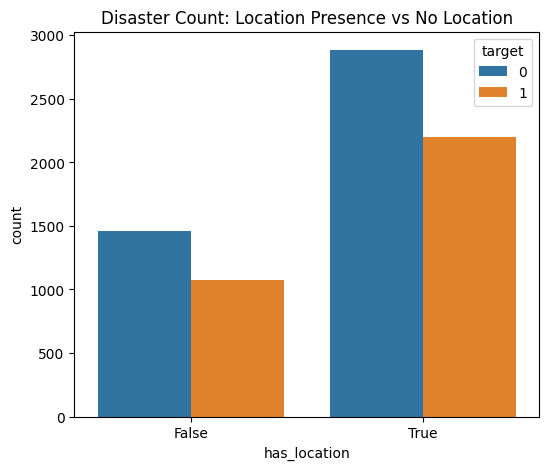

In [19]:
df["has_location"] = df["location"].notna()

location_analysis = df.groupby("has_location")["target"].value_counts(normalize=True).unstack()
print("Proportion of targets based on location presence:")
display(location_analysis)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="has_location", hue="target")
plt.title("Disaster Count: Location Presence vs No Location")
plt.show()

We observe that the proportion of positive and negative labels remains almost the same regardless of whether a tweet includes a location: 42.4% vs 43.2% (less than a 1% difference). This suggests that the presence of a location field does not provide significant discriminative value.

> *Conclusion: We will remove this field during the data preparation step.*

### 1.3 Keyword Presence vs Target

Does having a keyword associated with the tweet make it more likely to be a disaster? We'll analyze the percentage of disaster tweets for those with and without keywords.

Proportion of targets based on keyword presence:


target,0,1
has_keyword,,
False,0.311475,0.688525
True,0.572431,0.427569


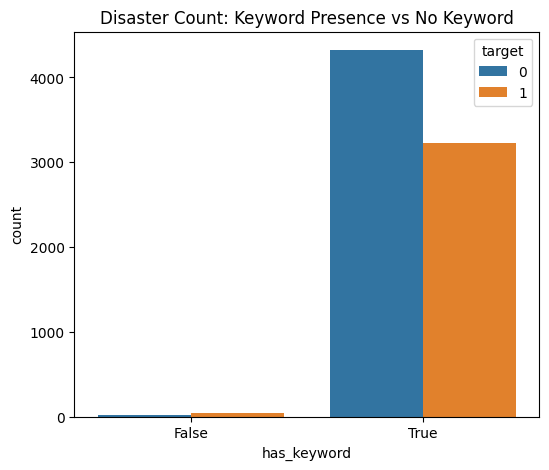

In [16]:
df["has_keyword"] = df["keyword"].notna()

keyword_analysis = df.groupby("has_keyword")["target"].value_counts(normalize=True).unstack()
print("Proportion of targets based on keyword presence:")
display(keyword_analysis)

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="has_keyword", hue="target")
plt.title("Disaster Count: Keyword Presence vs No Keyword")
plt.show()

When `has_keyword` is False (missing keyword), about 68.8% of these tweets are labeled as disasters (target = 1), while only 31.1% are not.

When `has_keyword` is True (keyword present), only 42.7% of these tweets are disasters, whereas 57.2% are not.

This indicates that tweets without an assigned keyword (i.e., null values) are significantly more likely to correspond to real disasters.

To further investigate this pattern, we will analyze whether these keywords are derived directly from the tweet text or come from an external source.

In [ ]:
def check_keyword_in_text(row) -> bool:
    """
    Check whether the 'keyword' field is inside the 'text' field.

    Args:
        row: Dataframe row.
    Returns:
        bool: Indicating whether the keyword is or not in the text.
    """
    if pd.isna(row["keyword"]):
        return None
    # Keywords in this dataset often use %20 for spaces, so we replace it
    keyword_clean = row["keyword"].replace("%20", " ").lower()
    return keyword_clean in row["text"].lower()

In [21]:
sample_with_keywords = df[df["keyword"].notna()].copy()
sample_with_keywords["is_keyword_in_text"] = sample_with_keywords.apply(check_keyword_in_text, axis=1)

print(f"Percentage of rows where the keyword is found in the text: {sample_with_keywords["is_keyword_in_text"].mean():.2%}")

Percentage of rows where the keyword is found in the text: 88.72%


According to our calculations, almost 90% of the tweets contain the keyword within the text itself. This suggests that the keyword may have been extracted directly from the tweet. The remaining ~10% could differ, especially since keywords are not normalized—meaning even a small variation (e.g., a single character) results in a different token.

Based on this, we will retain the `keyword` field for our baseline model, as this “crafted” feature may help improve performance. We will evaluate the baseline both with and without this feature.

However, for the BERT-base model, we will not include the keyword field. Transformer-based models like BERT are typically capable of capturing such patterns directly from the raw text, making this additional feature likely redundant.

### 1.4 Emojis and Hashtags Presence vs Target
Let's see if the use of emojis or hashtags is more common in one class than the other.

In [25]:
hashtag_pct = df['has_hashtag'].mean() * 100
emoji_pct = df['has_emoji'].mean() * 100

print(f"Percentage of tweets with hashtags: {hashtag_pct:.2f}%")
print(f"Percentage of tweets with emojis: {emoji_pct:.2f}%")

Percentage of tweets with hashtags: 23.13%
Percentage of tweets with emojis: 0.00%


We can observe that there are no emojis present in the dataset. It was worth verifying this, as social media posts—especially tweets—often include emojis.

However, since 23% of the examples contain at least one hashtag (`#`) in their text, we will analyze the relationship between the presence of hashtags and the target variable.

In [27]:
def has_hashtag(text) -> bool:
    """
    Detects if provided text contains a '#' in it.

    Args:
        text (str): Text to check.
    Returns:
        bool: Whether the text contains or not a hashtag.
    """
    return "#" in text

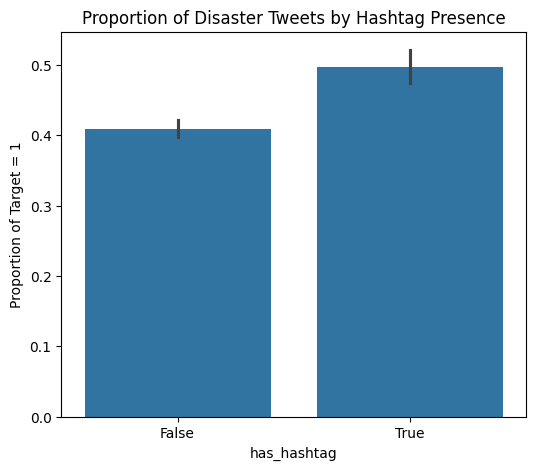


Hashtag Analysis (Proportions):


target,0,1
has_hashtag,,
False,0.590567,0.409433
True,0.503123,0.496877


In [29]:
df["has_hashtag"] = df["text"].apply(has_hashtag)

plt.figure(figsize=(6, 5))
sns.barplot(data=df, x="has_hashtag", y="target")
plt.title("Proportion of Disaster Tweets by Hashtag Presence")
plt.ylabel("Proportion of Target = 1")
plt.show()

print("\nHashtag Analysis (Proportions):")
display(df.groupby("has_hashtag")["target"].value_counts(normalize=True).unstack())

We observe that tweets containing a hashtag (`#`) are almost evenly split between DISASTER (1) and NOT_DISASTER (0). In contrast, tweets without hashtags tend to be more frequently labeled as NOT_DISASTER, with an approximate distribution of 60% vs 40%.

Although this indicates some difference, it is not strong enough to conclude that the presence or absence of hashtags alone is a decisive factor. Instead, it may act as a weak signal that could be useful when combined with other features.

For this reason, we will continue to monitor the impact of hashtags throughout the notebook, evaluating whether they contribute useful information or introduce noise into the model’s predictions.

### 0.5 EDA Conclusion

Based on the analysis conducted so far, we observe that the dataset is imbalanced towards the NOT_DISASTER (0) class by approximately 28%. This indicates that we need to pay close attention to this issue during both training and evaluation.

To address this imbalance, we will explore several strategies, including:
- Stratified data splitting to preserve label distribution
- Weighted loss functions (e.g., class weighting, Focal Loss)
- Oversampling the minority class or undersampling the majority class
- Careful metric selection (precision, recall, F1-score instead of accuracy)

Additionally, we analyzed the extra fields present in the dataset: `keyword` and `location`.

- The `keyword` field will be retained for the baseline model, as it may provide useful signal for TF-IDF-based approaches. However, it will be excluded from the BERT-base model, since transformer models are capable of capturing such patterns directly from raw text through their tokenization and architecture.
  
- The `location` field does not show a significant relationship with the target variable, as the label distribution remains nearly identical whether it is present or not. Therefore, it will be removed from the dataset for both experiments.

We will now proceed to the data preprocessing stage.

---
## 2. Data Preprocessing

In this section, we will split the dataset into training (80%), validation (10%), and test (10%) sets, while maintaining the class distribution using stratified sampling.

> *Note: In future experiments, we may explore additional preprocessing steps.*

In [9]:
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    df["text"], df["target"], test_size=0.1, random_state=42, stratify=df["target"], shuffle=True
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_temp, y_train_temp, test_size=0.1111, random_state=42, stratify=y_train_temp, shuffle=True
)

print(f"Training set: {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Validation set: {len(X_validation)} ({len(X_validation)/len(df):.1%})")
print(f"Test set: {len(X_test)} ({len(X_test)/len(df):.1%})")

Training set: 6089 (80.0%)
Validation set: 762 (10.0%)
Test set: 762 (10.0%)


---
## 3. Baseline Model

For our baseline model, which we will aim to improve in the next stage, we will use a combination of TF-IDF vectorization and a Logistic Regression classifier. This approach follows a more traditional Machine Learning paradigm.

### 3.1 TF-IDF

We will vectorize our sentences using the `TfidfVectorizer` from sklearn to generate our vectors.


In [19]:
vectorizer = TfidfVectorizer(stop_words="english",
                             max_features=50000,
                             sublinear_tf=True)

tfidf_matrix_train = vectorizer.fit_transform(X_train)
tfidf_matrix_validation = vectorizer.transform(X_validation)
tfidf_matrix_test = vectorizer.transform(X_test)

### 3.2 Logistic Regression Model

We will use the default hyperparameters, as we will not perform hyperparameter optimization (HPO) for the baseline model.

Both the baseline and the final model will be evaluated using the F1-score, which is the primary metric used in the competition.

In [32]:
# Setup Model
lg_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="saga",
    n_jobs=-1,
    random_state=42
)
# Train Model
lg_clf.fit(tfidf_matrix_train, y_train)

# Evaluate Train
print(f"Baseline Training F1-Score: {f1_score(y_train, lg_clf.predict(tfidf_matrix_train)):.3f}")

Baseline Training F1-Score: 0.863


To optimize the model’s performance, we will perform an F1-score threshold search. This involves identifying the optimal classification threshold that maximizes the F1-score, rather than relying on the default threshold.

In [36]:
val_probs = lg_clf.predict_proba(tfidf_matrix_validation)[:, 1]

# Search for the best threshold
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_validation, val_probs >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1-Score (Validation Set): {best_f1:.3f}")

Best threshold: 0.49
Best F1-Score (Validation Set): 0.779


> *Note: We will be using `0.49` as our classification threshold for the baseline.*

In [38]:
test_probs = lg_clf.predict_proba(tfidf_matrix_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print(f"Test F1-Score: {f1_score(y_test, test_preds):.3f}")

Test F1-Score: 0.745


### 3.3 Baseline Conclusion

After training a Logistic Regression model on TF-IDF (sparse) features, we achieve an F1-score of `0.745` on the test set. This result will serve as our baseline for comparison with the BERT-base model.

---
## 4. Transformer-based Models Experimentation

As introduced earlier, we will experiment with four different transformer-based models. All models will be fully fine-tuned, as we have a sufficiently sized dataset and aim to explore the performance ceiling for this task.

> *Note: The code for hyperparameter optimization (HPO), training, and evaluation will be shared across all experiments. To avoid duplication, we will reuse the same pipeline while only changing the model configuration. All results will be documented at the end of this section.*

### Why test four different models?

The primary distinction lies between:
- **General-purpose language models** (e.g., BERT), and  
- **Domain-specific models** trained on tweets (e.g., BERTweet, pre-trained on approximately 850 million English tweets over 7 years).

Additionally, we aim to evaluate the impact of **model size** (i.e., number of trainable parameters) on performance, comparing base vs large variants.


We will begin by loading the tokenizer and model, followed by preprocessing the dataset using the Hugging Face ecosystem (Datasets and Trainer). For hyperparameter optimization (HPO), we will use Optuna.

In [5]:
MODEL_NAME = "google-bert/bert-large-uncased"

### 4.1 Create Dataset

In [ ]:
df = df.rename(columns={"target": "label"})
df = df.drop(columns=["keyword", "location"], axis=1)

dataset = Dataset.from_pandas(df=df)
dataset = dataset.class_encode_column("label")

train_test = dataset.train_test_split(test_size=0.2,
                                      seed=22,
                                      stratify_by_column="label")
val_test = train_test["test"].train_test_split(test_size=0.5,
                                               seed=42, stratify_by_column="label")

dataset = DatasetDict({
    "train": train_test["train"],
    "validation": val_test["train"],
    "test": val_test["test"]
})
print(dataset)

### 4.2 Tokenization

In this sub-section we will load the model's tokenizer and use it to tokenize our dataset.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, normalization=True)

In [10]:
lengths = [len(tokenizer.encode(text)) for text in df["text"]]
print(f"Max tokens: {max(lengths)}")
print(f"95th percentile: {sorted(lengths)[int(len(lengths)*0.95)]}")

Max tokens: 84
95th percentile: 53


We analyze the data to determine the optimal maximum token length, ensuring that we do not waste computational resources or introduce excessive padding in our input representations. The best max_length is `84`.

In [11]:
def tokenize_examples(examples: list[dict[str, Any]]):
    """
    Tokenize sentences. Padding is deferred to the DataCollator so every
    batch pads to its own longest sequence instead of a fixed 84.
    """
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=84,
    )

In [ ]:
dataset = dataset.map(tokenize_examples, batched=True)

### 4.3 Model Architecture



In [13]:
FREEZE_BASE = False

def init_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    if FREEZE_BASE:
        for param in model.roberta.parameters():
            param.requires_grad = False

        for param in model.roberta.encoder.layer[-2:].parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    print(f"Successfully initialized `{MODEL_NAME}` model (freeze_base={FREEZE_BASE})")
    return model

Below are the total and trainable parameter counts for each model:

- **vinai/bertweet-base**
  - Total parameters: 134,901,506  
  - Trainable parameters: 134,901,506  

- **vinai/bertweet-large**
  - Total parameters: 355,361,794  
  - Trainable parameters: 355,361,794  

- **bert-base-uncased**
  - Total parameters: 109,483,778  
  - Trainable parameters: 109,483,778  

- **bert-large-uncased**
  - Total parameters: 335,143,938  
  - Trainable parameters: 335,143,938  

### 4.4 Hyperparameter Optimization (HPO)

#### 4.4.1 Load Evaluation Metrics

In [ ]:
binary_metrics = evaluate.combine(["accuracy", "precision", "recall", "f1"])

def compute_metrics(eval_pred):
    """
    Return accuracy/precision/recall/F1.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    results = binary_metrics.compute(predictions=predictions, references=labels)
    return results

#### 4.4.2 Trainer Setup & Hyperparameter Search


In [17]:
data_collator = DataCollatorWithPadding(tokenizer, max_length=84, padding="max_length")

In [ ]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = TrainingArguments(
    output_dir="./hpo_results",
    # Training/Evaluation cadence
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="no",
    logging_steps=50,
    per_device_eval_batch_size=64,
    # Reproducibility
    seed=42,
    data_seed=42,
    # Selection
    metric_for_best_model="f1",
    greater_is_better=True,
    # Hardware
    bf16=use_bf16,
    fp16=use_fp16,
    dataloader_num_workers=2,
    report_to="none",
)

trainer = Trainer(
    model_init=init_model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [126]:
def hp_space(trial: optuna.Trial) -> dict[str, Any]:
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-5, log=True),  # tightened
        "num_train_epochs": trial.suggest_categorical("num_train_epochs", [3, 4]),  # drop 5, larger model overfits faster
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [16, 32]),
        "gradient_accumulation_steps": trial.suggest_categorical("gradient_accumulation_steps", [1, 2]),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.06, 0.1),  # more warmup for larger model
        "weight_decay": trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True),
    }

#### 4.4.3 Run HPO Trials

In [ ]:
NUM_TRIALS = 15

best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=hp_space,
    n_trials=NUM_TRIALS,
    sampler=TPESampler(seed=22),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=200, interval_steps=200)
)

print("Best trial:")
print(f"  Objective (eval_f1): {best_run.objective:.4f}")
print(f"  Hyperparameters: {best_run.hyperparameters}")

In [ ]:
# 1. Update training arguments with best hyperparameters
for n, v in best_run.hyperparameters.items():
    setattr(trainer.args, n, v)

# 2. Fix checkpoint saving
trainer.args.save_strategy = "steps"
trainer.args.save_steps = 200
trainer.args.load_best_model_at_end = True

# 3. Reinitialize model from pretrained weights
trainer.model = init_model()

# 4. Train
trainer.train()

print("Final model training complete.")

# 5. Threshold tuning on val
val_output = trainer.predict(dataset["validation"])
val_probs = softmax(val_output.predictions, axis=1)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(val_output.label_ids, val_probs >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best Val F1: {max(f1_scores):.4f}")

# 6. Evaluate on test
test_output = trainer.predict(dataset["test"])
test_probs = softmax(test_output.predictions, axis=1)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)
print(f"Test F1: {f1_score(dataset['test']['label'], test_preds):.4f}")

### 4.5 Experiment Results

#### Baseline

| Model | Val F1 | Test F1 | Threshold |
|-------|--------|---------|-----------|
| TF-IDF + Logistic Regression | 0.779 | 0.745 | 0.49 |

**Best hyperparameters:** `max_features=50000`, `sublinear_tf=True`, `C=1.0`, `max_iter=1000`, `solver=saga`

<br/>

#### Experiment 1 — BERTweet-base

| Model | Val F1 | Test F1 | Threshold | HPO Trials |
|-------|--------|---------|-----------|------------|
| vinai/bertweet-base | 0.845 | 0.779 | 0.52 | 25 |

**Best hyperparameters:** `lr=3.2e-5`, `epochs=4`, `batch=32`, `grad_acc=2`, `warmup=0.048`, `weight_decay=0.024`

<br/>

#### Experiment 2 — BERTweet-large

| Model | Val F1 | Test F1 | Threshold | HPO Trials |
|-------|--------|---------|-----------|------------|
| vinai/bertweet-large | 0.836 | 0.795 | 0.51 | 25 |

**Best hyperparameters:** `lr=1.1e-5`, `epochs=4`, `batch=32`, `grad_acc=2`, `warmup=0.081`, `weight_decay=0.0001`

<br/>

#### Experiment 3 — bert-base-uncased (ablation)

| Model | Val F1 | Test F1 | Threshold | HPO Trials |
|-------|--------|---------|-----------|------------|
| google-bert/bert-base-uncased | 0.849 | 0.796 | 0.54 | 15 |

**Best hyperparameters:** `lr=1.5e-5`, `epochs=3`, `batch=16`, `grad_acc=1`, `warmup=0.095`, `weight_decay=0.006`

**Observation:** This model performs competitively with BERTweet-large despite lacking tweet-specific pretraining. This suggests that the task may rely more on general language understanding than domain-specific knowledge.

<br/>

#### Experiment 4 — bert-large-uncased

| Model | Val F1 | Test F1 | Threshold | HPO Trials |
|-------|--------|---------|-----------|------------|
| google-bert/bert-large-uncased | 0.8485 | 0.8078 | 0.47 | 15 |

**Best hyperparameters:**  
`lr=1.48e-5`, `epochs=4`, `batch=32`, `grad_acc=2`, `warmup=0.091`, `weight_decay=0.00039`

<br/>

#### Additional Experiments

All four transformer models achieved relatively similar performance, with F1-scores around ~0.80. BERTweet-base performed slightly worse (\~3% lower), while the other three models were nearly equivalent.

To further explore potential improvements, we conducted additional experiments:

- **Focal Loss:**  
  We trained the same models using Focal Loss to address class imbalance. However, this did not improve performance, with results averaging around ~0.79 F1. This suggests that the dataset imbalance may not be severe enough for Focal Loss to provide benefits.

- **Train + Validation Merge:**  
  We combined the training and validation sets (increasing training data by ~10%). This resulted in a slightly lower F1-score (\~0.785), indicating that the original split provided better generalization.

<br/>

#### Next Steps

The next step is to conduct a detailed error analysis to better understand model failures and identify potential areas for improvement. If no clear gains are found, we may explore alternative architectures or techniques to break the current performance ceiling.

<br/>

### Final Model Selection

We select **`bert-large-uncased`** as the final model, as it achieved the highest test F1-score (~0.808), outperforming the others by approximately 1%.

However, to validate this result, we will test multiple random seeds to ensure that the performance is consistent and not due to variance in training. This will help confirm whether the observed improvement is robust.

> *Note: Seed variation results in approximately ±1-2% fluctuation in F1-score.*

## 5. Submission

### 5.1 Loading Data

In [15]:
DATASET_PATH = "/content/test.csv"
submission_df = pd.read_csv(filepath_or_buffer=DATASET_PATH)

print(f"Submission (Test) dataset loaded successfully with {len(submission_df)} examples (no labels)")

Submission (Test) dataset loaded successfully with 3263 examples (no labels)


### 5.2 Preparing Data

In [ ]:
def tokenize_test(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=84,
        padding="max_length"
    )

# Prepare the Kaggle test set for inference
submission_dataset = Dataset.from_pandas(submission_df[["id", "text"]])
submission_dataset = submission_dataset.map(tokenize_test, batched=True)
print("Submission dataset tokenized.")

### 5.3 Making Predictions

In [ ]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

# Best hyperparameters from Experiment 4
final_args = TrainingArguments(
    output_dir="./final_submission_model",
    learning_rate=1.48e-5,
    num_train_epochs=4,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=2,
    warmup_ratio=0.091,
    weight_decay=0.00039,
    bf16=use_bf16,
    fp16=use_fp16,
    logging_steps=50,
    save_strategy="no",
    report_to="none"
)

# Initialize and train the final model
final_model = init_model()
submission_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=dataset["train"],
    data_collator=data_collator,
)

print("Re-training model for final submission...")
submission_trainer.train()

# Inference on Kaggle test set
raw_preds = submission_trainer.predict(submission_dataset)
final_probs = softmax(raw_preds.predictions, axis=1)[:, 1]

submission_preds = (final_probs >= 0.47).astype(int)
print("Inference complete.")

### 5.4 Saving Predictions

In [ ]:
submission_df = pd.DataFrame({
    "id": submission_df["id"],
    "target": submission_preds
})

submission_df.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' created successfully.")
display(submission_df.head())